# Combined Bandit Algorithm 

Applies all the contextual bandit algorithms to the synthetic SPF scam dataset:
- **BayesianUCB** - upper confidence bounds with Bayesian posterior updates
- **NormalThompsonSampling** - non-contextual baseline using Beta posteriors and binary updates
- **LinUCB** — disjoint linear UCB with one-hot arm context augmentation
- **Contextual Thompson Sampling** — Bayesian posterior sampling over linear reward weights

In [382]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(4014)

In [ ]:
DATA_PATH = './data/synthetic_spf_scam_cases_1H2025.csv'
df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,}')
df.head()

Rows: 19,665


,case_id,age_group,scam_type,contact_method,source_platform,requires_user_action,payment_method,urgency_level,loss_bucket,transaction_amount,is_scam
0,1,30-49,Job,Classified Ads,Classifieds,1,Card,Medium,2k-5k,3721.57,1
1,2,20-29,Phishing,Classified Ads,Classifieds,1,E-wallet,Medium,2k-5k,2168.36,1
2,3,20-29,Job,Phone Call,Phone,1,E-wallet,High,5k-10k,5811.74,1
3,4,30-49,Phishing,Social Media,Facebook,1,Card,Medium,<2k,187.44,1
4,5,<20,Job,Messaging,WhatsApp,1,E-wallet,Medium,10k-50k,12426.74,1


## Feature engineering
Transform the raw data into features for the model to learn at each action to understand which arm performs best for different types of users or scenarios.

In [5]:
categorical_features = ['age_group', 'scam_type', 'source_platform', 'payment_method', 'urgency_level', 'loss_bucket']

feature_df = pd.get_dummies(df[categorical_features], drop_first=True)
feature_df['requires_user_action'] = df['requires_user_action'].astype(float)
feature_df['log_amount'] = np.log1p(df['transaction_amount'])

feature_matrix = feature_df.to_numpy(dtype=float)
feature_columns = feature_df.columns.tolist()

# z score normalisation of feature matrix
scaler = StandardScaler()
feature_matrix = scaler.fit_transform(feature_matrix)

print(f'Feature matrix shape: {feature_matrix.shape}')
feature_df.head()

Feature matrix shape: (19665, 46)


,age_group_30-49,age_group_50-64,age_group_65+,age_group_<20,scam_type_Fake Friend Call,scam_type_Government Impersonation,scam_type_Insurance Services,scam_type_Internet Love,scam_type_Investment,scam_type_Job,...,payment_method_PayNow/Transfer,urgency_level_Low,urgency_level_Medium,loss_bucket_10k-50k,loss_bucket_2k-5k,loss_bucket_50k-100k,loss_bucket_5k-10k,loss_bucket_<2k,requires_user_action,log_amount
0,1,0,0,0,0,0,0,0,0,1,...,0,0,1,0,1,0,0,0,1.0,8.222170
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,1.0,7.682187
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1.0,8.667807
3,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1.0,5.238780
4,0,0,0,1,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1.0,9.427686


## Arm declaration

In [6]:
class InterventionArm:
    def __init__(self, arm_id, name, friction, effectiveness):
        self.arm_id = arm_id
        self.name = name
        self.friction = friction
        self.effectiveness = effectiveness

ARMS = [
    InterventionArm(arm_id=0, name='Self-guided checklist',          friction=0.05, effectiveness=0.20),
    InterventionArm(arm_id=1, name='Digital footprint scan',         friction=0.15, effectiveness=0.50),
    InterventionArm(arm_id=2, name='Redirect to official channels',  friction=0.30, effectiveness=0.70),
    InterventionArm(arm_id=3, name='Schedule transaction',           friction=0.50, effectiveness=0.85),
    InterventionArm(arm_id=4, name='Mandatory bank consultation',    friction=0.80, effectiveness=0.95),
]

n_arms = len(ARMS)
arm_names = [arm.name for arm in ARMS]
n_features = feature_matrix.shape[1]

# Simulated ground-truth reward weights per arm
true_thetas = np.random.normal(0, 1, size=(n_arms, n_features))
true_thetas[3] += 1.5  # Schedule transaction
true_thetas[4] += 2.0  # Mandatory bank consultation

## Thompson Sampling implementation

In [ ]:
class NormalThompsonSampling:

    def __init__(self, n_arms: int, init_alpha: float = 1.0, init_beta: float = 1.0):
        self.n_arms = n_arms
        self.init_alpha = init_alpha
        self.init_beta  = init_beta
        self.alphas  = [init_alpha] * n_arms   
        self.betas   = [init_beta]  * n_arms   
        self.counts  = [0] * n_arms
        self.values  = [0.0] * n_arms     

    def select_arm(self) -> int:
        """Sample from each arm's Beta posterior, return arm with highest sample."""
        samples = [
            random.betavariate(self.alphas[i], self.betas[i])
            for i in range(self.n_arms)
        ]
        return samples.index(max(samples))
    
    def _reset(self):
        """Resets the learner's memory back to a blank slate for a new simulation."""
        self.alphas = [self.init_alpha] * self.n_arms
        self.betas  = [self.init_beta]  * self.n_arms
        self.counts = [0] * self.n_arms
        self.values = [0.0] * self.n_arms

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
    
        self.values[chosen_arm] = ((n - 1) / n) * self.values[chosen_arm] + (1 / n) * reward

        p = 1.0 / (1.0 + np.exp(-reward / 100.0)) 
    
        if np.random.random() < p:
            self.alphas[chosen_arm] += 1
        else:
            self.betas[chosen_arm] += 1
    
    def act_and_learn(self, context: np.ndarray, reward_fn) -> dict:
        """This wrapper allows your algo to run in their simulation loop."""
        arm = self.select_arm()
        reward = reward_fn(arm, context)
        self.update(arm, reward)

        dummy_thetas = np.zeros((self.n_arms, len(context))) 
    
        dummy_scores = np.zeros(self.n_arms)
    
        return {
            'arm': arm, 
            'reward': reward, 
            'thetas': dummy_thetas, 
            'scores': dummy_scores
        }

## LinUCB implementation

In [ ]:
class LinUCB:
    def __init__(self, n_arms: int, n_features: int, alpha: float):
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha
        self.A = [np.identity(n_features) for _ in range(n_arms)]  
        self.b = [np.zeros(n_features) for _ in range(n_arms)]  

    def _reset(self):
        self.A = [np.identity(self.n_features) for _ in range(self.n_arms)]
        self.b = [np.zeros(self.n_features) for _ in range(self.n_arms)]
        self.t = 0

    def update(self, arm: int, context: np.ndarray, reward: float) -> None:
        self.A[arm] += np.outer(context, context)
        self.b[arm] += reward * context

    def recommend(self, context_matrix: np.ndarray):
        scores = np.zeros(self.n_arms)
        thetas = [np.zeros(self.n_features) for _ in range(self.n_arms)]

        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta = A_inv @ self.b[arm]
            p_arm = theta.T @ context_matrix[arm] + self.alpha * np.sqrt(context_matrix[arm].T @ A_inv @ context_matrix[arm])
            scores[arm] = p_arm
            thetas[arm] = theta

        return int(np.argmax(scores)), thetas, scores
    
    def augment_context(self, x, arm, n_arms):
        arm_one_hot = np.zeros(n_arms)
        arm_one_hot[arm] = 1
        return np.concatenate([x, arm_one_hot])
    
    def act_and_learn(self, context: np.ndarray, reward_fn) -> dict:
        self.t += 1
        context_matrix = np.array([self.augment_context(context, arm, n_arms) for arm in range(self.n_arms)])

        arm_selected, thetas, scores = self.recommend(context_matrix)

        observed_reward = reward_fn(arm_selected, context)
        self.update(arm_selected, context_matrix[arm_selected], observed_reward)

        return {'arm': arm_selected, 'reward': observed_reward, 'thetas': np.array(thetas), 'scores': scores}

## Contextual Thompson Sampling implementation

In [ ]:
class ContextualThompsonSampling:
    def __init__(self, n_arms: int, context_dim: int, v: float = 1.0):
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.v = v
        self._reset()

    def _reset(self):
        d = self.context_dim
        self.B  = [0.1 * np.eye(d) for _ in range(self.n_arms)]  
        self.f  = [np.zeros(d) for _ in range(self.n_arms)]  
        self.mu = [np.zeros(d) for _ in range(self.n_arms)]  
        self.t = 0
        self.history = []

    def update(self, arm: int, context: np.ndarray, reward: float):
        x = np.asarray(context, dtype=float)
        self.B[arm]  += np.outer(x, x)
        self.f[arm]  += x * reward
        self.mu[arm]  = np.linalg.solve(self.B[arm], self.f[arm])
        self.history.append({'arm': arm, 'reward': reward}) 

    def select_arm(self, context: np.ndarray) -> int:
        x = np.asarray(context, dtype=float)
        expected_rewards = []

        for a in range(self.n_arms):
            cov = self.v**2 * np.linalg.inv(self.B[a])
            theta_sample = np.random.multivariate_normal(self.mu[a], cov)
            expected_rewards.append(x @ theta_sample)

        return int(np.argmax(expected_rewards))

    def act_and_learn(self, context: np.ndarray, reward_fn) -> dict:
        self.t += 1
        x = np.asarray(context, dtype=float)
        
        sampled_thetas = []
        scores = []

        for a in range(self.n_arms):
            # posterior_cov
            A_inv = np.linalg.inv(self.B[a])
            cov = (self.v**2) * A_inv + (1e-6 * np.eye(self.context_dim))
            
            theta_sample = np.random.multivariate_normal(self.mu[a], cov)
            sampled_thetas.append(theta_sample)
            scores.append(x @ theta_sample)

        arm_selected = int(np.argmax(scores))
        reward = reward_fn(arm_selected, context)

        # update results
        self.B[arm_selected] += np.outer(x, x)
        self.f[arm_selected] += x * reward
        self.mu[arm_selected] = np.linalg.solve(self.B[arm_selected], self.f[arm_selected])

        return {'arm': arm_selected, 'reward': reward, 'thetas': np.array(sampled_thetas), 'scores': np.array(scores)}

    def posterior_mean(self, arm: int) -> np.ndarray:
        return self.mu[arm].copy()

    def posterior_cov(self, arm: int) -> np.ndarray:
        return self.v**2 * np.linalg.inv(self.B[arm]) + 1e-6 * np.eye(self.context_dim)

## Bayesian UCB Implementation

In [11]:
class BayesianUCB:

    def __init__(self, n_arms: int, context_dim: int, v: float = 1.0, beta: float = 1.96):
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.v = v
        self.beta = beta
        self._reset()

    def _reset(self):
        d = self.context_dim
        self.B = [np.eye(d) for _ in range(self.n_arms)]      
        self.f = [np.zeros(d) for _ in range(self.n_arms)]    
        self.mu = [np.zeros(d) for _ in range(self.n_arms)]   
        self.t = 0
        self.history = []

    def update(self, arm: int, context: np.ndarray, reward: float):
        x = np.asarray(context, dtype=float)
        self.B[arm] += np.outer(x, x)
        self.f[arm] += x * reward
        self.mu[arm] = np.linalg.solve(self.B[arm], self.f[arm])

    def posterior_cov(self, arm: int) -> np.ndarray:
        return self.v**2 * np.linalg.inv(self.B[arm])

    def score_arm(self, arm: int, context: np.ndarray) -> float:
        x = np.asarray(context, dtype=float)
        mu_a = self.mu[arm]
        cov_a = self.posterior_cov(arm)

        mean_reward = x @ mu_a
        std_reward = np.sqrt(np.clip(x @ cov_a @ x, 0.0, None))

        return float(mean_reward + self.beta * std_reward)

    def select_arm(self, context: np.ndarray) -> int:
        scores = [self.score_arm(a, context) for a in range(self.n_arms)]
        return int(np.argmax(scores))

    def act_and_learn(self, context: np.ndarray, reward_fn) -> dict:
        self.t += 1
        arm = self.select_arm(context)
        reward = reward_fn(arm, context)
        self.update(arm, context, reward)

        scores = np.array([self.score_arm(a, context) for a in range(self.n_arms)])
        info = {
            't': self.t,
            'arm': arm,
            'reward': reward,
            'scores': scores
        }
        self.history.append(info)
        
        return info

## Environment for contextual bandit

In [ ]:
class Environment:
    def __init__(self, feature_matrix: np.ndarray, arms: list, df: pd.DataFrame, reward_noise_scale: float = 0.1, domain_reward_scale: float = 500.0):
        self.feature_matrix = feature_matrix
        self.arms = arms
        self.df = df
        self.n_arms = len(arms)
        self.context_dim = feature_matrix.shape[1]
        self.true_theta = np.random.randn(self.n_arms, self.context_dim) * 0.3
        for arm_id in range(self.n_arms):
            self.true_theta[arm_id] *= arms[arm_id].effectiveness
        self.reward_noise_scale = reward_noise_scale
        self.domain_reward_scale = domain_reward_scale

    def compute_reward(self, arm_id: int, context: np.ndarray, scam_prob: float, transaction_amount: float, urgency: float, alpha: float = 0.5, add_noise: bool = True) -> float:
        arm = self.arms[arm_id]
        linear_term       = context @ self.true_theta[arm_id]
        financial_benefit = scam_prob * transaction_amount * arm.effectiveness
        friction_penalty  = (1 - scam_prob) * arm.friction * urgency
        domain_term = financial_benefit - friction_penalty
        domain_term_normalised = np.tanh(domain_term / self.domain_reward_scale) # normalise reward

        reward = ((1-alpha) * linear_term) + (alpha * domain_term_normalised)

        if add_noise:
            reward += np.random.normal(0, self.reward_noise_scale)

        return float(reward)

    def sample_context(self) -> Tuple[np.ndarray, float, float, float]:
        idx     = np.random.randint(0, len(self.feature_matrix))
        context = self.feature_matrix[idx].copy()
        sample  = self.df.iloc[idx]
        scam_prob = float(sample['is_scam'])
        amount    = float(sample['transaction_amount'])
        urgency_map = {'Low': 1.0, 'Medium': 2.0, 'High': 3.0}
        urgency = urgency_map.get(sample['urgency_level'], 2) / 3.0
        return context, scam_prob, amount, urgency

    def optimal_arm(self, context, scam_prob, amount, urgency, alpha: float = 0.5, add_noise=False) -> int:
        rewards = [self.compute_reward(arm_id, context, scam_prob, amount, urgency, alpha, add_noise=False) for arm_id in range(self.n_arms)]
        return int(np.argmax(rewards))

    def optimal_reward(self, context, scam_prob, amount, urgency, alpha) -> float:
        arm = self.optimal_arm(context, scam_prob, amount, urgency, alpha, add_noise=False)
        return self.compute_reward(arm, context, scam_prob, amount, urgency, alpha=alpha, add_noise=False)

In [15]:
alpha = 0.5
augmented_n_features = n_features + n_arms

# add domain reward scale
env   = Environment(feature_matrix, ARMS, df, reward_noise_scale=0.1, domain_reward_scale=1000.0)
agents = [
            BayesianUCB(n_arms=n_arms, context_dim=feature_matrix.shape[1], v=1.0, beta=1.96),
            NormalThompsonSampling(n_arms=n_arms),
            LinUCB(n_arms=n_arms, n_features=augmented_n_features, alpha=alpha),
            ContextualThompsonSampling(n_arms=n_arms, context_dim=feature_matrix.shape[1], v=1.0)
        ]

In [ ]:
N_SIMULATIONS = 100
N_TIMESTEPS   = 1000
print(len(feature_matrix))
results = {}

for agent in agents:
    name = type(agent).__name__
    results[name] = {
        'rewards': np.zeros((N_SIMULATIONS, N_TIMESTEPS)),
        'regrets': np.zeros((N_SIMULATIONS, N_TIMESTEPS)),
        'arms': np.zeros((N_SIMULATIONS, N_TIMESTEPS), dtype=int),
        # 'arm_entropy': [],
    }
    print(name)

    for sim in range(N_SIMULATIONS):
        agent._reset()

        for t in range(N_TIMESTEPS):
            context, scam_prob, amount, urgency = env.sample_context()

            def reward_fn(arm, ctx):
                return env.compute_reward(arm, ctx, scam_prob, amount, urgency, alpha=0.5)

            info   = agent.act_and_learn(context, reward_fn)
            opt_r  = env.optimal_reward(context, scam_prob, amount, urgency, alpha=0.5)
            regret = opt_r - info['reward']

            results[name]['rewards'][sim, t] = info['reward']
            results[name]['regrets'][sim, t] = opt_r - info['reward']
            results[name]['arms'][sim, t]    = info['arm']

19665
BayesianUCB
NormalThompsonSampling
LinUCB
ContextualThompsonSampling


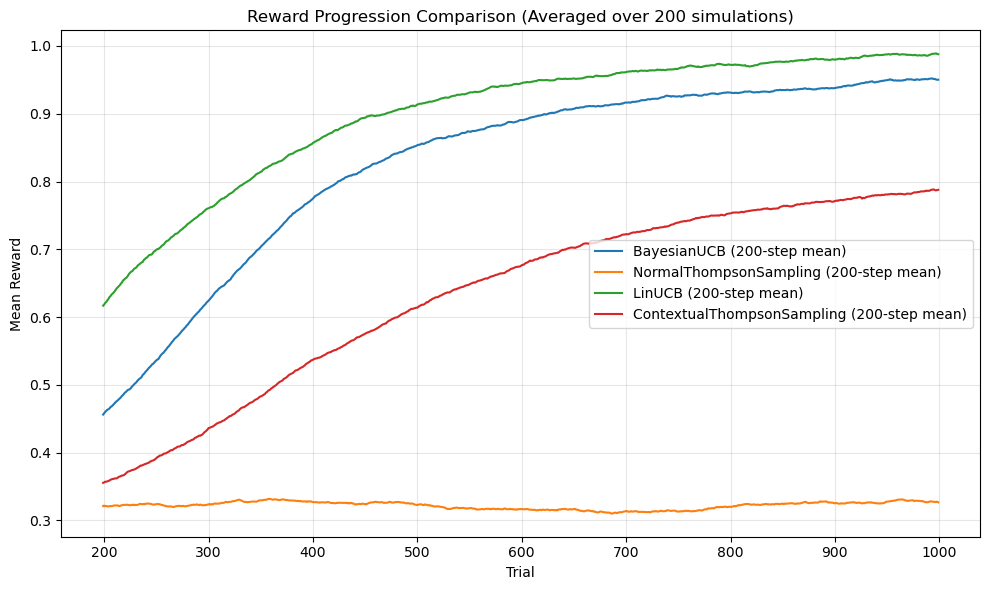

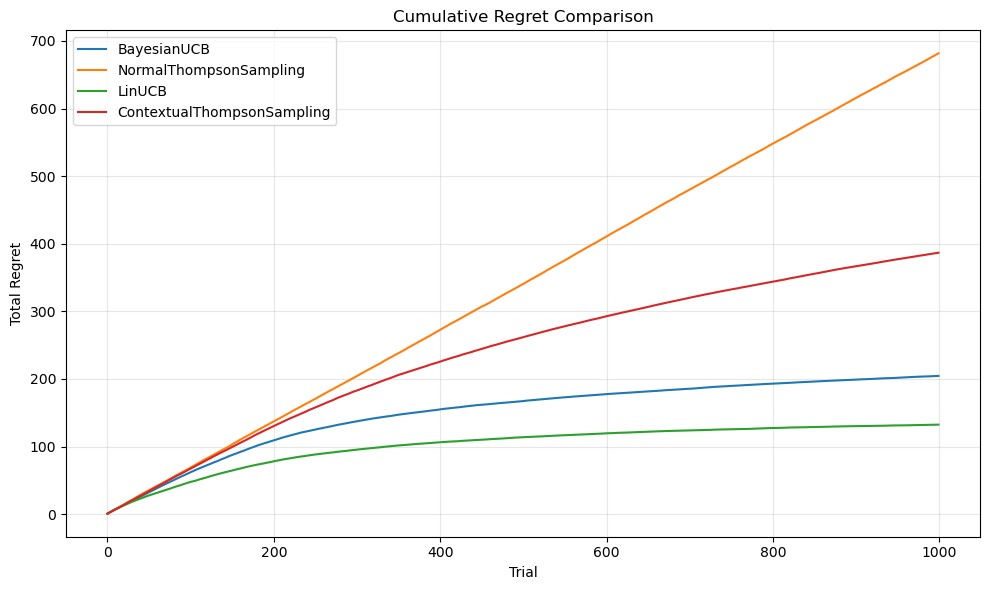

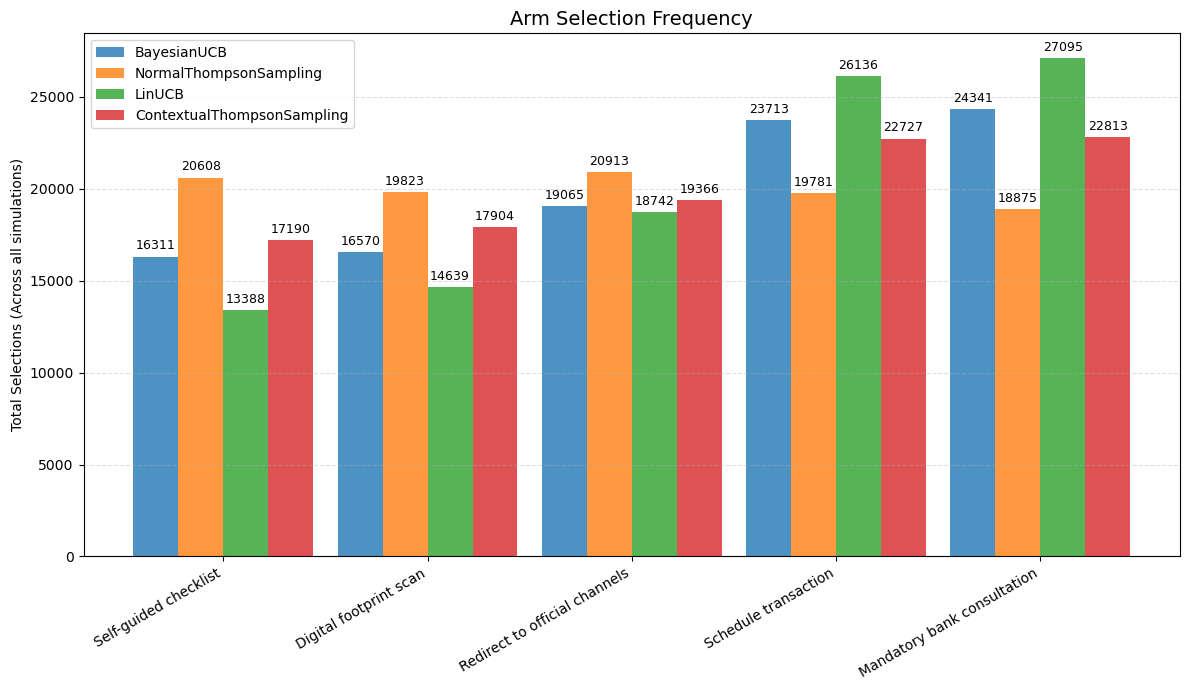

In [23]:
window = 200

plt.figure(figsize=(10, 6))
for name, data in results.items():
    # mean reward across all 200 simulations at each timestep
    mean_reward_t = np.mean(data['rewards'], axis=0)
    rolling_reward = pd.Series(mean_reward_t).rolling(window).mean()
    
    plt.plot(rolling_reward, label=f'{name} ({window}-step mean)')
plt.title('Reward Progression Comparison (Averaged over 200 simulations)')
plt.xlabel('Trial')
plt.ylabel('Mean Reward')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for name, data in results.items():
    # calculate mean regret at each step then cumsum it
    mean_regret_t = np.mean(data['regrets'], axis=0)
    cumulative_regret = np.cumsum(mean_regret_t)
    
    plt.plot(cumulative_regret, label=name)
plt.title('Cumulative Regret Comparison')
plt.xlabel('Trial')
plt.ylabel('Total Regret')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
n_arms = len(ARMS)
n_agents = len(results)
x = np.arange(n_arms)
width = 0.22
for i, (name, data) in enumerate(results.items()):
    unique_arms, counts = np.unique(data['arms'], return_counts=True)
    arm_counts_dict = dict(zip(unique_arms, counts))
    display_counts = [arm_counts_dict.get(j, 0) for j in range(n_arms)]
    offset = (i - (n_agents - 1) / 2) * width
    rects = ax.bar(x + offset, display_counts, width, label=name, alpha=0.8)
    ax.bar_label(rects, padding=3, fmt='%d', fontsize=9)
ax.set_ylabel('Total Selections (Across all simulations)')
ax.set_title('Arm Selection Frequency', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(arm_names, rotation=30, ha='right')
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()